# Assignment 2

**COMP5329 / Deep Learning — University of Sydney, Semester 1 2026**

## Connect with OLLAMA

In [ ]:
# Install ollama
!curl -fsSL https://ollama.com/install.sh | sh   # linux / mac
!irm https://ollama.com/install.ps1 | iex        # windows

# then download these models
!ollama pull tinyllama
!ollama pull llama3.2:1b
!ollama pull llama3.2:3b

/bin/bash: line 1: ollama: command not found


In [37]:
import requests

# ensure ollama service is running, else manually start using 'ollama serve' 
OLLAMA_URL = "http://localhost:11434/api/generate"
TARGET_MODEL = "tinyllama"

payload = {
    "model": TARGET_MODEL,
    "prompt": "What is 2 + 2? Answer only the number.",
    "stream": False
}

response = requests.post(OLLAMA_URL, json=payload)
print(response.json()["response"])

Answer: 4


## Synthetic Dataset Generator for Positional Bias Experiment (0-shot prompting)

We construct a synthetic dataset to evaluate positional bias in large language models (LLMs) by measuring their ability to retrieve relevant information from different locations within a context. Each sample consists of a set of textual facts describing multiple fictional projects, among which exactly one fact contains the correct answer.

For each sample, a target project is randomly selected from a predefined pool of project names, and a corresponding five-digit identifier code is generated as the ground truth. The relevant evidence sentence is constructed in the form: “The identifier code for Project X is Y.” This sentence is embedded within a larger context composed of distractor facts.

Distractor sentences follow a similar syntactic structure but vary along two dimensions: project names and key types. Project names are drawn either from a standard set (e.g., Aurora, Orion, Vega) or from a confusable set containing closely related variants (e.g., AuroraX, Aurora-Prime). Similarly, distractor keys include both clearly distinct attributes (e.g., access code, backup code, server pin) and semantically similar variants (e.g., identifier token, identification code, reference code). Numerical values for distractors are randomly generated, with constraints ensuring that the correct answer is unique and not duplicated elsewhere in the context.

To increase task difficulty, we introduce controlled variation across three difficulty levels: easy, medium, and hard. In the easy setting, distractors use distinct project names and keys. In the medium setting, confusable project names are introduced. In the hard setting, both confusable project names and semantically similar keys are used, and distractors may also include multiple references to the target project with incorrect attributes. This design forces the model to jointly reason over both the project identity and the attribute type, rather than relying on simple keyword matching.

We systematically vary two primary independent variables: context length and evidence position. Context length has three levels: short (20 distractors), medium (60 distractors), and long (120 distractors). Evidence position has three levels: beginning, middle, and end, determined by where the correct sentence is inserted within the context. This enables analysis of primacy and recency effects as well as degradation in middle-context retrieval.

Each sample is formatted as a zero-shot question-answering prompt, where the model is asked to identify the identifier code for the target project and instructed to return only the numeric value. The dataset is generated in a fully factorial manner across difficulty levels, context lengths, and evidence positions. By default, 10 samples are generated per condition, yielding a total of 540 samples (3 difficulties × 3 context lengths × 3 positions × 20 samples per condition). The dataset is shuffled prior to evaluation to eliminate ordering effects.

Model performance is evaluated using exact-match accuracy, computed by extracting the first five-digit number from the model output and comparing it with the ground truth. This controlled experimental setup enables systematic analysis of positional bias, including primacy effects, recency effects, and performance degradation in mid-context regions, while also examining how these effects interact with task difficulty and model capacity.

In [ ]:
"""
Synthetic dataset generator for a positional-bias experiment.

The dataset tests whether LLM retrieval accuracy changes when the relevant
evidence appears at the beginning, middle, or end of a context.

The generator also varies:
    1. context length
    2. task difficulty
    3. evidence position

Output:
    positional_bias_dataset.jsonl
"""

from __future__ import annotations

import json
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Literal


# ---------------------------------------------------------------------
# Type aliases
# ---------------------------------------------------------------------

Position = Literal["beginning", "middle", "end"]
ContextLength = Literal["short", "medium", "long"]
Difficulty = Literal["easy", "medium", "hard"]


# ---------------------------------------------------------------------
# Experiment constants
# ---------------------------------------------------------------------

POSITIONS: tuple[Position, ...] = ("beginning", "middle", "end")

CONTEXT_CONFIGS: dict[ContextLength, int] = {
    "short": 20,
    "medium": 60,
    "long": 120,
}

EASY_PROJECT_NAMES = [
    "Aurora", "Orion", "Lyra", "Vega", "Nimbus", "Atlas",
    "Helios", "Nova", "Echo", "Titan", "Solace", "Zephyr",
]

CONFUSING_PROJECT_NAMES = [
    "Aurora", "AuroraX", "Aurora-Prime",
    "Orion", "OrionX", "Orion-Prime",
    "Lyra", "LyraX", "Lyra-Prime",
    "Vega", "VegaX", "Vega-Prime",
]

EASY_DISTRACTOR_KEYS = [
    "access code",
    "backup code",
    "archive key",
    "server pin",
]

CONFUSING_DISTRACTOR_KEYS = [
    "identifier token",
    "identification code",
    "internal code",
    "reference code",
    "identifier code",
    "access code",
    "backup code",
    "archive key",
    "server pin",
]

QUESTION_TEMPLATES: dict[Difficulty, str] = {
    "easy": "What is the identifier code for Project {project}?",
    "medium": "Find the identifier code assigned to Project {project}.",
    "hard": "Which five-digit number is the identifier code associated with Project {project}?",
}


@dataclass(frozen=True)
class DifficultyConfig:
    """Controls how challenging each task variant is."""

    use_CONFUSING_projects: bool
    use_CONFUSING_keys: bool


DIFFICULTY_CONFIGS: dict[Difficulty, DifficultyConfig] = {
    "easy": DifficultyConfig(
        use_CONFUSING_projects=False,
        use_CONFUSING_keys=False,
    ),
    "medium": DifficultyConfig(
        use_CONFUSING_projects=True,
        use_CONFUSING_keys=False,
    ),
    "hard": DifficultyConfig(
        use_CONFUSING_projects=True,
        use_CONFUSING_keys=True,
    ),
}


# ---------------------------------------------------------------------
# Data containers
# ---------------------------------------------------------------------

@dataclass(frozen=True)
class DatasetConfig:
    """Configuration for the full dataset generation run."""

    samples_per_condition: int = 20
    random_seed: int = 42
    output_path: Path = Path("positional_bias_dataset.jsonl")
    shuffle: bool = True


@dataclass(frozen=True)
class Sample:
    """One synthetic retrieval example."""

    sample_id: int
    difficulty: Difficulty
    context_length: ContextLength
    num_distractors: int
    evidence_position: Position
    target_project: str
    gold_answer: str
    evidence_sentence: str
    prompt: str


class PositionalBiasDatasetGenerator:
    """Generate controlled prompts for studying positional bias in LLMs."""

    def __init__(self, config: DatasetConfig) -> None:
        self.config = config
        self.rng = random.Random(config.random_seed)

    def generate_code(self) -> str:
        """Generate a five-digit numeric label."""
        return str(self.rng.randint(10000, 99999))

    @staticmethod
    def get_project_pool(difficulty: Difficulty) -> list[str]:
        """Select project names based on task difficulty."""
        config = DIFFICULTY_CONFIGS[difficulty]
        return (
            CONFUSING_PROJECT_NAMES
            if config.use_CONFUSING_projects
            else EASY_PROJECT_NAMES
        )

    @staticmethod
    def get_distractor_keys(difficulty: Difficulty) -> list[str]:
        """Select distractor key types based on task difficulty."""
        config = DIFFICULTY_CONFIGS[difficulty]
        return (
            CONFUSING_DISTRACTOR_KEYS
            if config.use_CONFUSING_keys
            else EASY_DISTRACTOR_KEYS
        )

    def make_distractor_fact(
        self,
        target_project: str,
        gold_answer: str,
        project_names: list[str],
        distractor_keys: list[str],
        allow_same_project: bool,
    ) -> str:
        """Create a non-answer fact."""

        while True:
            project = self.rng.choice(project_names)
            key = self.rng.choice(distractor_keys)
            value = self.generate_code()

            # No duplicate correct answers
            if value == gold_answer:
                continue

            # Control difficulty
            if not allow_same_project and project == target_project:
                continue

            return f"The {key} for Project {project} is {value}."

    @staticmethod
    def insert_evidence(
        distractors: list[str],
        evidence: str,
        position: Position,
    ) -> list[str]:
        """
        Insert the correct evidence at a controlled position.

        This is the main experimental manipulation.
        """
        if position == "beginning":
            return [evidence, *distractors]

        if position == "middle":
            middle_index = len(distractors) // 2
            return [
                *distractors[:middle_index],
                evidence,
                *distractors[middle_index:],
            ]

        if position == "end":
            return [*distractors, evidence]

        raise ValueError(f"Unsupported evidence position: {position}")

    @staticmethod
    def build_prompt(
        context_facts: list[str],
        target_project: str,
        difficulty: Difficulty,
    ) -> str:
        """Build the final model prompt."""
        context = "\n".join(context_facts)
        question = QUESTION_TEMPLATES[difficulty].format(project=target_project)

        return f"""This is a synthetic benchmark. Use the context to answer the question. Return only the final number.

Context:
{context}

Question:
{question}

Answer:"""

    def generate_sample(
        self,
        sample_id: int,
        difficulty: Difficulty,
        context_length: ContextLength,
        evidence_position: Position,
    ) -> Sample:
        """Generate one controlled synthetic retrieval sample."""
        project_names = self.get_project_pool(difficulty)
        distractor_keys = self.get_distractor_keys(difficulty)

        target_project = self.rng.choice(project_names)
        gold_answer = self.generate_code()

        evidence_sentence = (
            f"The identifier code for Project {target_project} is {gold_answer}."
        )

        num_distractors = CONTEXT_CONFIGS[context_length]

        distractors = [
            self.make_distractor_fact(
                target_project=target_project,
                gold_answer=gold_answer,
                project_names=project_names,
                distractor_keys=distractor_keys,
                allow_same_project = difficulty in ["hard"],
            )
            for _ in range(num_distractors)
        ]

        context_facts = self.insert_evidence(
            distractors=distractors,
            evidence=evidence_sentence,
            position=evidence_position,
        )

        prompt = self.build_prompt(
            context_facts=context_facts,
            target_project=target_project,
            difficulty=difficulty,
        )

        return Sample(
            sample_id=sample_id,
            difficulty=difficulty,
            context_length=context_length,
            num_distractors=num_distractors,
            evidence_position=evidence_position,
            target_project=target_project,
            gold_answer=gold_answer,
            evidence_sentence=evidence_sentence,
            prompt=prompt,
        )

    def generate_dataset(self) -> list[Sample]:
        """
        Generate a balanced dataset.

        Total samples =
            difficulties × context lengths × positions × samples_per_condition
        """
        dataset: list[Sample] = []

        for difficulty in DIFFICULTY_CONFIGS:
            for context_length in CONTEXT_CONFIGS:
                for evidence_position in POSITIONS:
                    for _ in range(self.config.samples_per_condition):
                        dataset.append(
                            self.generate_sample(
                                sample_id=len(dataset),
                                difficulty=difficulty,
                                context_length=context_length,
                                evidence_position=evidence_position,
                            )
                        )

        if self.config.shuffle:
            self.rng.shuffle(dataset)

        return dataset

    @staticmethod
    def save_jsonl(samples: list[Sample], output_path: Path) -> None:
        """Save generated samples as JSONL."""
        with output_path.open("w", encoding="utf-8") as file:
            for sample in samples:
                file.write(json.dumps(asdict(sample), ensure_ascii=False) + "\n")

        print(f"Saved {len(samples)} samples to {output_path}")


def main() -> None:
    """Generate and save the positional-bias dataset."""
    config = DatasetConfig()
    generator = PositionalBiasDatasetGenerator(config)

    dataset = generator.generate_dataset()
    generator.save_jsonl(dataset, config.output_path)


if __name__ == "__main__":
    main()

Saved 540 samples to positional_bias_dataset.jsonl


## Model Evaluation and Experimental Setup

To evaluate positional bias across models of varying capacity, we conduct controlled experiments using multiple instruction-tuned large language models accessed via a local inference framework. Specifically, we evaluate TinyLlama, Llama 3.2 1B, and Llama 3.2 3B, representing a spectrum of model capacities from very small to moderately sized models. TinyLlama serves as an extreme low-capacity baseline, enabling analysis of failure modes and instability in retrieval tasks, while the LLaMA 3.2 models provide progressively stronger instruction-following capabilities.

All experiments are conducted using a zero-shot prompting setup. Each sample from the synthetic dataset is passed directly to the model without any additional examples or fine-tuning. To ensure consistent output formatting across models, the original prompt is augmented with an explicit instruction requiring the model to return exactly one five-digit numeric value. This constraint standardises responses and enables reliable evaluation.

Model inference is performed through a local API endpoint, where each prompt is processed independently. Decoding is configured to be deterministic, with temperature set to zero and nucleus sampling disabled (top-p = 1), ensuring reproducibility and eliminating stochastic variation in outputs. A fixed maximum token generation limit is used to constrain output length.

For each dataset sample, the model output is post-processed using a regular expression to extract the first five-digit number. This extracted value is compared against the ground truth identifier code using an exact-match criterion. A prediction is considered correct only if the extracted number exactly matches the ground truth. Outputs that do not contain a valid five-digit number are treated as incorrect predictions. Additionally, failed requests or inference errors are recorded to ensure robustness in evaluation.

Evaluation is performed across all combinations of difficulty level, context length, and evidence position defined in the dataset. Each sample is evaluated independently for each model, resulting in a fully crossed experimental design. For computational efficiency during development, experiments may be conducted on a subset of the dataset; however, final results are reported on the complete dataset.

Results are aggregated by grouping predictions according to model, difficulty, context length, and evidence position. For each group, we compute total samples, number of correct predictions, and exact-match accuracy. This enables detailed analysis of positional bias, including primacy and recency effects, as well as performance degradation in mid-context regions.

This setup ensures that all models are evaluated on identical inputs under consistent conditions, allowing observed differences in performance to be attributed to model capacity rather than variations in data or prompting.

In [63]:
"""
Run positional-bias evaluation across multiple Ollama models.
"""

from __future__ import annotations

import json
import re
import time
from pathlib import Path
from typing import Any

import pandas as pd
import requests


DATASET_PATH = Path("positional_bias_dataset.jsonl")
RESULTS_PATH = Path("positional_bias_results.jsonl")
SUMMARY_PATH = Path("positional_bias_summary.csv")

OLLAMA_GENERATE_URL = "http://localhost:11434/api/generate"

MODELS = [
    "tinyllama",
    "llama3.2:1b",
    "llama3.2:3b",
]

REQUEST_TIMEOUT_SECONDS = 600
SLEEP_BETWEEN_REQUESTS = 0.2
MAX_SAMPLES: int | None = None


def load_jsonl(path: Path) -> list[dict[str, Any]]:
    """Load dataset rows from JSONL as dictionaries."""
    with path.open("r", encoding="utf-8") as file:
        return [json.loads(line) for line in file]


def append_jsonl(row: dict[str, Any], path: Path) -> None:
    """Append one result row to a JSONL output file."""
    with path.open("a", encoding="utf-8") as file:
        file.write(json.dumps(row, ensure_ascii=False) + "\n")


def extract_first_five_digit_code(text: str) -> str | None:
    """Extract the first five-digit number from model output."""
    match = re.search(r"\b\d{5}\b", text)
    return match.group(0) if match else None


def build_eval_prompt(original_prompt: str) -> str:
    """Wrap the original prompt with stricter output rules."""
    return f"""{original_prompt}

STRICT OUTPUT RULE:
Return exactly one five-digit number.
Do not return words, punctuation, explanation, or markdown.
"""


def query_ollama(model: str, prompt: str) -> str:
    """Run one Ollama model call."""
    payload = {
        "model": model,
        "prompt": build_eval_prompt(prompt),
        "stream": False,
        "options": {
            "temperature": 0,
            "top_p": 1,
            "num_predict": 32,
        },
    }

    response = requests.post(
        OLLAMA_GENERATE_URL,
        json=payload,
        timeout=REQUEST_TIMEOUT_SECONDS,
    )
    response.raise_for_status()

    return response.json().get("response", "").strip()


def run_experiment() -> None:
    """Run all samples through all selected models."""
    dataset = load_jsonl(DATASET_PATH)

    if MAX_SAMPLES is not None:
        dataset = dataset[:MAX_SAMPLES]

    if RESULTS_PATH.exists():
        RESULTS_PATH.unlink()

    total_runs = len(dataset) * len(MODELS)
    run_counter = 0

    print(f"Loaded {len(dataset)} samples")
    print(f"Models: {MODELS}")
    print(f"Total runs: {total_runs}")
    print(f"Writing results to: {RESULTS_PATH}")

    for model in MODELS:
        print(f"\n=== Running model: {model} ===")

        for sample in dataset:
            run_counter += 1
            gold_answer = sample["gold_answer"]

            try:
                raw_response = query_ollama(model, sample["prompt"])
                predicted_answer = extract_first_five_digit_code(raw_response)
                is_correct = predicted_answer == gold_answer
                error = None

            except Exception as exc:
                raw_response = ""
                predicted_answer = None
                is_correct = False
                error = repr(exc)

            result = {
                "sample_id": sample["sample_id"],
                "model": model,
                "difficulty": sample.get("difficulty"),
                "context_length": sample["context_length"],
                "num_distractors": sample["num_distractors"],
                "evidence_position": sample["evidence_position"],
                "target_project": sample["target_project"],
                "gold_answer": gold_answer,
                "predicted_answer": predicted_answer,
                "raw_response": raw_response,
                "is_correct": is_correct,
                "error": error,
            }

            append_jsonl(result, RESULTS_PATH)

            print(
                f"[{run_counter}/{total_runs}] "
                f"model={model} | "
                f"id={sample['sample_id']} | "
                f"difficulty={sample.get('difficulty')} | "
                f"context={sample['context_length']} | "
                f"position={sample['evidence_position']} | "
                f"gold={gold_answer} | "
                f"pred={predicted_answer} | "
                f"correct={is_correct}"
            )

            if predicted_answer is None:
                print(f"  raw_response={repr(raw_response[:300])}")
                print(f"  error={error}")

            time.sleep(SLEEP_BETWEEN_REQUESTS)

    create_summary()


def create_summary() -> None:
    """Summarise accuracy by model, difficulty, context length, and position."""
    df = pd.DataFrame(load_jsonl(RESULTS_PATH))

    summary = (
        df.groupby(["model", "difficulty", "context_length", "evidence_position"])
        .agg(
            total_samples=("sample_id", "count"),
            correct=("is_correct", "sum"),
            accuracy=("is_correct", "mean"),
            failed_requests=("error", lambda x: x.notna().sum()),
        )
        .reset_index()
        .sort_values(["model", "difficulty", "context_length", "evidence_position"])
    )

    summary.to_csv(SUMMARY_PATH, index=False)

    print("\nAccuracy summary:")
    print(summary)
    print(f"\nSaved summary to: {SUMMARY_PATH}")


if __name__ == "__main__":
    run_experiment()

Loaded 540 samples
Models: ['tinyllama', 'llama3.2:1b', 'llama3.2:3b']
Total runs: 1620
Writing results to: positional_bias_results.jsonl

=== Running model: tinyllama ===
[1/1620] model=tinyllama | id=124 | difficulty=easy | context=long | position=beginning | gold=76694 | pred=12345 | correct=False
[2/1620] model=tinyllama | id=52 | difficulty=easy | context=short | position=end | gold=76247 | pred=76247 | correct=True
[3/1620] model=tinyllama | id=56 | difficulty=easy | context=short | position=end | gold=19661 | pred=19661 | correct=True
[4/1620] model=tinyllama | id=519 | difficulty=hard | context=long | position=middle | gold=24157 | pred=52621 | correct=False
[5/1620] model=tinyllama | id=421 | difficulty=hard | context=medium | position=beginning | gold=68138 | pred=None | correct=False
  raw_response='The answer to the question is "Project Vega".'
  error=None
[6/1620] model=tinyllama | id=103 | difficulty=easy | context=medium | position=end | gold=23226 | pred=23226 | correc

## Visual Comparison

To analyse positional bias across models and experimental conditions, we perform a structured visual comparison of model performance using aggregated accuracy metrics. Visualisation serves as the primary tool for identifying systematic trends such as **primacy effects**, **recency effects**, and **degradation in middle-context retrieval**.

All plots are generated from the aggregated results file, which contains exact-match accuracy computed for each combination of model, difficulty level, context length, and evidence position. Categorical variables are explicitly ordered to ensure consistent comparisons, with models arranged by increasing capacity (TinyLlama, LLaMA 3.2 1B, LLaMA 3.2 3B) and evidence positions ordered as Beginning, Middle, and End.

### Positional Bias Dot Plots

The primary visualisation consists of **dot plots** showing accuracy as a function of evidence position. Separate plots are generated for each context length condition (short, medium, long), with each model represented by a distinct marker and accuracy computed as the mean exact-match score.

To improve readability, a small amount of horizontal jitter and transparency (alpha) are applied to points. No connecting lines are used, as evidence position is categorical, and legends are placed outside the plot area to avoid occlusion. These plots enable direct comparison of positional performance across models and context lengths.

### Difficulty-Specific Analysis

To isolate the effect of task complexity, the analysis is repeated using only samples from the **hard difficulty setting**, which introduces confusable project names, semantically similar distractor keys, and same-project distractors. This allows assessment of how positional bias interacts with task difficulty and whether model robustness degrades under more complex conditions.

### Edge vs Middle Comparison

To quantify the **“lost-in-the-middle” effect**, beginning and end positions are collapsed into an **Edge** category and compared against the **Middle** position. Accuracy is aggregated using total correct predictions and total samples, and results are visualised using bar charts for each context length. This provides a simplified and interpretable comparison of boundary versus mid-context performance.

### Interpretation Strategy

The visual comparison framework supports three key analyses:

- **Positional bias detection**, by identifying U-shaped accuracy patterns (Beginning ≈ End > Middle)  
- **Model capacity effects**, by comparing performance across models of increasing size  
- **Context-length interaction**, by examining whether positional bias becomes more pronounced as context length increases  

By combining dot plots, difficulty-specific analysis, and edge-versus-middle comparisons, this methodology provides a comprehensive and interpretable framework for analysing positional bias in LLMs under controlled conditions.

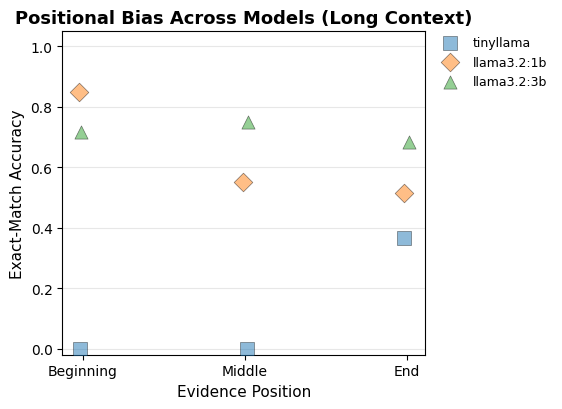

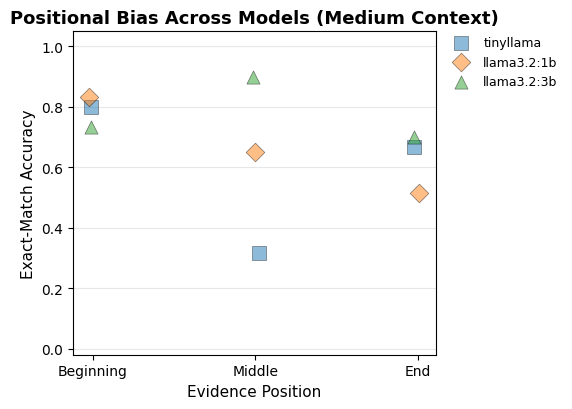

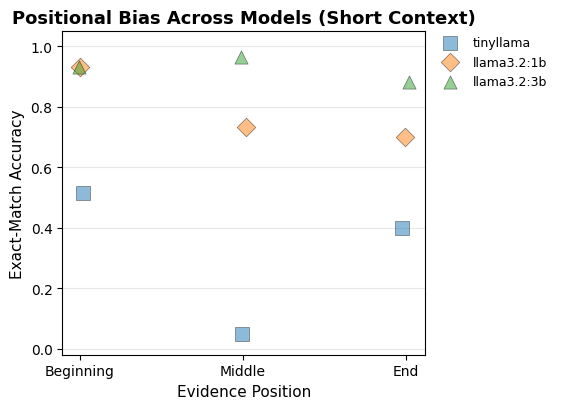

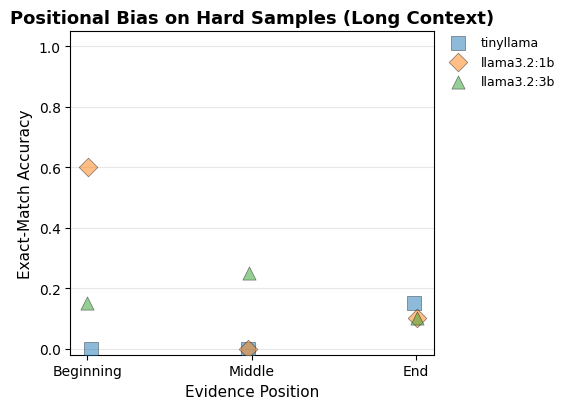

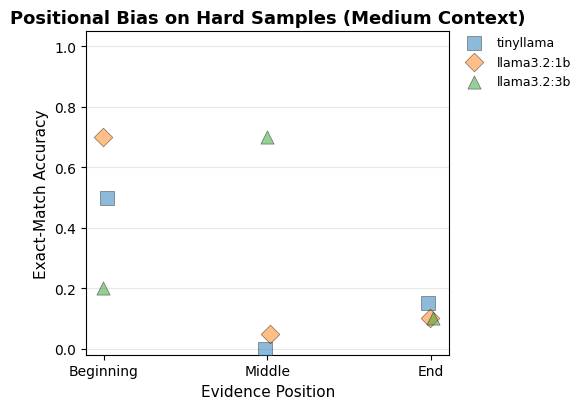

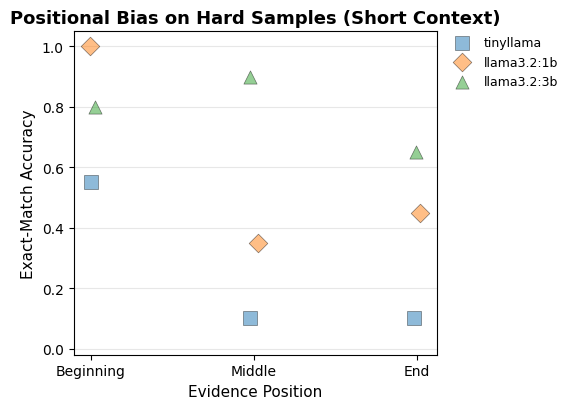

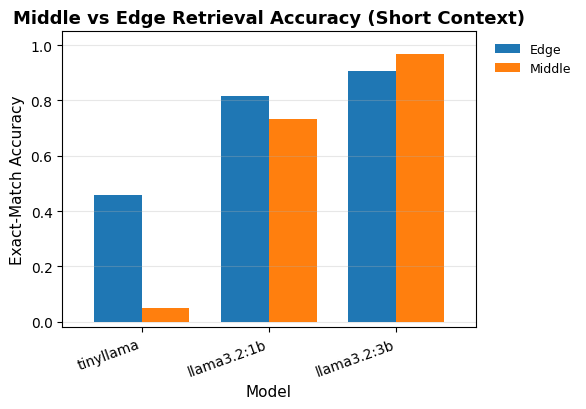

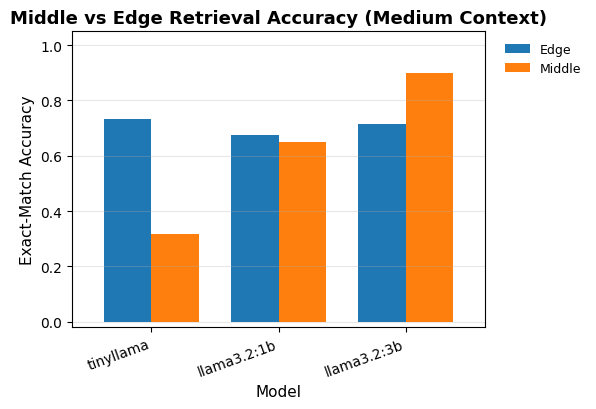

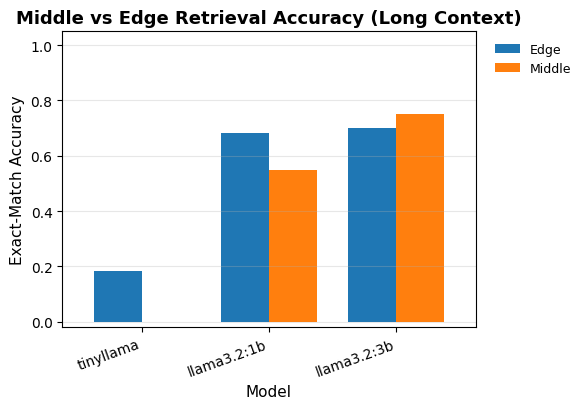

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# -----------------------------
# Load data
# -----------------------------

INPUT_CSV = "positional_bias_summary.csv"
OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(INPUT_CSV)

position_order = ["beginning", "middle", "end"]
context_order = ["short", "medium", "long"]
difficulty_order = ["easy", "medium", "hard"]
model_order = ["tinyllama", "llama3.2:1b", "llama3.2:3b"]

df["model"] = pd.Categorical(
    df["model"],
    categories=model_order,
    ordered=True,
)

df["evidence_position"] = pd.Categorical(
    df["evidence_position"], categories=position_order, ordered=True
)
df["context_length"] = pd.Categorical(
    df["context_length"], categories=context_order, ordered=True
)
df["difficulty"] = pd.Categorical(
    df["difficulty"], categories=difficulty_order, ordered=True
)

position_to_x = {"beginning": 0, "middle": 1, "end": 2}
markers = ["o", "s", "D", "^", "v"]

# -----------------------------
# Plot style helper
# -----------------------------

def apply_publication_style(title: str) -> None:
    plt.title(title, fontsize=13, weight="bold")
    plt.xlabel("Evidence Position", fontsize=11)
    plt.ylabel("Exact-Match Accuracy", fontsize=11)
    plt.xticks([0, 1, 2], ["Beginning", "Middle", "End"])
    plt.ylim(-0.02, 1.05)
    plt.grid(axis="y", alpha=0.3)

    # Legend outside
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        fontsize=9,
        borderaxespad=0,
    )

    plt.tight_layout(rect=[0, 0, 0.8, 1])


# -----------------------------
# Dot plot
# -----------------------------

def plot_position_dotplot(data: pd.DataFrame, title: str, output_path: Path) -> None:
    plt.figure(figsize=(7.2, 4.2))

    for idx, model in enumerate(model_order):
        if model not in data["model"].astype(str).unique():
            continue
        model_data = (
            data[data["model"] == model]
            .groupby("evidence_position", observed=True)["accuracy"]
            .mean()
            .reset_index()
            .sort_values("evidence_position")
        )

        model_data["x"] = model_data["evidence_position"].astype(str).map(position_to_x)

        jitter = (np.random.rand(len(model_data)) - 0.5) * 0.05

        plt.scatter(
            model_data["x"] + jitter,
            model_data["accuracy"],
            s=90,
            marker=markers[idx % len(markers) + 1],
            label=model,
            alpha=0.5,
            edgecolors="black",
            linewidths=0.5,
            zorder=3,
        )

    apply_publication_style(title)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


# -----------------------------
# Figure 1
# -----------------------------

for context in df["context_length"].dropna().unique():
    subset_context = df[df["context_length"] == context]

    plot_position_dotplot(
        data=subset_context,
        title=f"Positional Bias Across Models ({str(context).capitalize()} Context)",
        output_path=OUTPUT_DIR / f"dot_positional_bias_{context}.png",
    )


# -----------------------------
# Figure 2
# -----------------------------

df_hard = df[df["difficulty"] == "hard"]

for context in df_hard["context_length"].dropna().unique():
    subset_context = df_hard[df_hard["context_length"] == context]

    plot_position_dotplot(
        data=subset_context,
        title=f"Positional Bias on Hard Samples ({str(context).capitalize()} Context)",
        output_path=OUTPUT_DIR / f"dot_positional_bias_hard_{context}.png",
    )


# -----------------------------
# Figure 3
# -----------------------------

df_edge = df.copy()
df_edge["position_group"] = df_edge["evidence_position"].apply(
    lambda x: "Middle" if x == "middle" else "Edge"
)

middle_edge_summary = (
    df_edge
    .groupby(["model", "context_length", "position_group"], observed=True)["accuracy"]
    .mean()
    .reset_index()
)

for context in middle_edge_summary["context_length"].dropna().unique():
    subset = middle_edge_summary[
        middle_edge_summary["context_length"] == context
    ]

    pivot = subset.pivot(
        index="model",
        columns="position_group",
        values="accuracy",
    )

    plt.figure(figsize=(7.5, 4.2))
    pivot.plot(kind="bar", ax=plt.gca(), width=0.75)

    plt.title(
        f"Middle vs Edge Retrieval Accuracy ({str(context).capitalize()} Context)",
        fontsize=13,
        weight="bold",
    )
    plt.xlabel("Model", fontsize=11)
    plt.ylabel("Exact-Match Accuracy", fontsize=11)
    plt.ylim(-0.02, 1.05)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)

    # Legend outside
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        fontsize=9,
    )

    plt.tight_layout(rect=[0, 0, 0.8, 1])

    output_path = OUTPUT_DIR / f"middle_vs_edge_{context}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()